# Exploratory Data Analysis (EDA)

## Objective

Analyze the distribution of toxic labels and understand characteristics of toxic comments.

### Questions

- How common is each toxic category?
- Is the dataset balanced?
- Do comments have multiple labels?
- Are toxic comments longer than non-toxic comments?

In [20]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [4]:
train =  pd.read_csv("../data/train.csv")
test = pd.read_csv('../data/test.csv')

### Percentage of Toxic Comments 

In [55]:
train['toxic'].value_counts(normalize=True)

toxic
0    0.904156
1    0.095844
Name: proportion, dtype: float64

In [56]:
labels = [
    "toxic",
    "severe_toxic",
    "obscene",
    "threat",
    "insult",
    "identity_hate"
]

In [57]:
## count positives
label_counts = train[labels].sum()
label_counts

toxic            15294
severe_toxic      1595
obscene           8449
threat             478
insult            7877
identity_hate     1405
dtype: int64

In [58]:
train[train["toxic"] == 1]["comment_text"].head()

6          COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK
12    Hey... what is it..\n@ | talk .\nWhat is it......
16    Bye! \n\nDon't look, come or think of comming ...
42    You are gay or antisemmitian? \n\nArchangel WH...
43             FUCK YOUR FILTHY MOTHER IN THE ASS, DRY!
Name: comment_text, dtype: str

## Label Distribution Visualization

Visual comparison of all target categories.

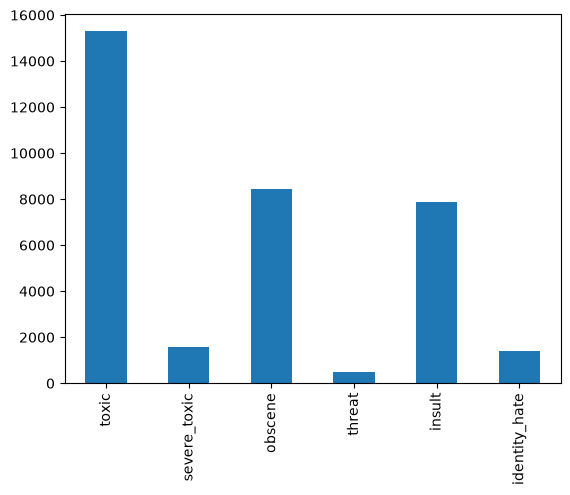

In [59]:
label_counts.plot(kind="bar")
plt.show()

In [60]:
# percentage of total toxic comments

(label_counts / len(train))*100

toxic            9.584448
severe_toxic     0.999555
obscene          5.294822
threat           0.299553
insult           4.936361
identity_hate    0.880486
dtype: float64

## Multi-Label Analysis

Investigate whether comments belong to multiple categories simultaneously.

In [67]:
train[labels].sum(axis=1).value_counts()
# 143,346 comments have no toxic labels
# 6,360 comments have exactly 1 label
# 3,480 comments have exactly 2 labels
# etc. 

0    143346
1      6360
3      4209
2      3480
4      1760
5       385
6        31
Name: count, dtype: int64

In [68]:
toxic_comments = train[train['toxic'] == 1]
toxic_comments['comment_text'].head(10)

6          COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK
12    Hey... what is it..\n@ | talk .\nWhat is it......
16    Bye! \n\nDon't look, come or think of comming ...
42    You are gay or antisemmitian? \n\nArchangel WH...
43             FUCK YOUR FILTHY MOTHER IN THE ASS, DRY!
44    I'm Sorry \n\nI'm sorry I screwed around with ...
51    GET FUCKED UP. GET FUCKEEED UP.  GOT A DRINK T...
55    Stupid peace of shit stop deleting my stuff as...
56    =Tony Sidaway is obviously a fistfuckee. He lo...
58    My Band Page's deletion. You thought I was gon...
Name: comment_text, dtype: str

In [69]:
non_toxic_comments = train[train["toxic"] == 0]
non_toxic_comments["comment_text"].head(10)

0     Explanation\nWhy the edits made under my usern...
1     D'aww! He matches this background colour I'm s...
2     Hey man, I'm really not trying to edit war. It...
3     "\nMore\nI can't make any real suggestions on ...
4     You, sir, are my hero. Any chance you remember...
5     "\n\nCongratulations from me as well, use the ...
7     Your vandalism to the Matt Shirvington article...
8     Sorry if the word 'nonsense' was offensive to ...
9     alignment on this subject and which are contra...
10    "\nFair use rationale for Image:Wonju.jpg\n\nT...
Name: comment_text, dtype: str

## Comment Length Analysis

Compare toxic and non-toxic comments based on character count and word count.

In [70]:
train["comment_len"] = train["comment_text"].apply(len)

train["word_count"] = train["comment_text"].apply(
    lambda x: len(x.split())
)


In [71]:
train.groupby("toxic")["comment_len"].mean()


toxic
0    404.549339
1    295.246044
Name: comment_len, dtype: float64

In [72]:
train.groupby("toxic")["word_count"].mean()

toxic
0    68.967874
1    51.289787
Name: word_count, dtype: float64

# Conclusions

### Observations

- Toxic comments represent approximately X% of the dataset.
- Threat is the rarest category.
- The dataset is highly imbalanced.
- Many comments belong to multiple categories.
- Toxic comments tend to be shorter than non-toxic comments.

### Next Steps

- Text preprocessing
- Tokenization
- Stopword removal
- TF-IDF feature extraction
- Baseline machine learning model